## Описание проекта

Автор проекта: Ким Алина

Дата: 08.03.26

Я провожу исследовательский анализ рынка общественного питания в Москве для инвесторов из фонда «Shut Up and Take My Money». Они планируют открыть новое заведение, но пока не определились с его форматом (кафе, ресторан или бар), расположением, меню и ценовой политикой. Моя задача — на основе данных о существующих заведениях Москвы (датасет от Яндекс Карт и Яндекс Бизнеса, лето 2022 года) выявить ключевые закономерности и тренды, чтобы помочь инвесторам принять обоснованное решение.

### Цель проекта

Проанализировать структуру рынка, популярные категории заведений, их расположение по районам, сетевые форматы, средние чеки, посадочные места и рейтинги, а также определить факторы, влияющие на успешность заведений. 

### Задачи проекта 
Анализ структуры рынка 
- Типы заведений
- Их концентрация по административным округам
- Изучение сетевых форматов
- Оценка факторов, влияющих на рейтинг и средний чек (количество посадочных мест, ценовая политика, расположение)

##  Загрузка данных о заведениях общественного питания Москвы

In [53]:
# Комментарий ревьюера
# Для задания по расчету корреляции требуется установить библиотеку
# Устанавливаем библиотеку phik
!pip install phik -U    
# Библиотека для расчета коэффициента корреляции phi_k
#from phik import phik_matrix

In [54]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix 

### Задача 1
Загрузите данные о заведениях общественного питания Москвы. 

In [55]:
rest_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv') 
display(rest_df, price_df)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0
...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN
...,...,...,...,...,...
4053,962800540173458486f3c465437c2d8b,средние,Цена бокала пива:от 140 ₽,NaN,NaN
4054,4277890d659341848d7051cbf2e51f51,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN
4055,026cbc478f9b4c3294a83458dcd89982,средние,NaN,NaN,NaN
4056,71cc394927204d45b81c3a91edb47955,NaN,Средний счёт:50–250 ₽,150.0,NaN


### Задача 2
Познакомьтесь с данными и изучите общую информацию о них.

In [56]:
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [57]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


### 1.3 Задача 3. 
##### Сделайте вывод о полученных данных: каков объём данных, соответствуют ли данные описанию, встречаются ли пропущенные значения, используются ли верные типы данных.
 В первом датасете представлено 9 столбцов и 8406 строк. Во втором датасете представлено 5 столбцов и 4058 строк.Числовые столбцы: rating (float64), chain (int64), seats (float64), middle_avg_bill (float64), middle_coffee_cup (float64).
Категориальные/текстовые: id, name, category, address, district, hours, price, avg_bill (object).  Столбцы имеют пропуски, seats, price, middle_avg_bill, middle_coffee_cup. Наибольшая доля пропусков в столбце middle_coffee_cup делает его малопригодным для анализа. Остальные пропуски связаны с отсутствием информации в исходных источниках и требуют обработки.  

#### 1.4 Задача 4.
##### Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [58]:
dva_df=rest_df.merge(price_df, how='outer', on='id')
display(dva_df)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0,NaN,NaN,NaN,NaN
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0,NaN,NaN,NaN,NaN
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,NaN,Средний счёт:от 150 ₽,150.0,NaN
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,NaN,NaN,NaN,NaN


Объединила 2 датасета. Применила outer, данный тип объединения заполняет отсутствующие значения на NaN и объединяет 2 датасета.

In [59]:
# Комментарий ревьюера
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
# только не надо эту копию потом использовать в проекте
temp = dva_df.copy() 
len(temp)

8406

## Обобщающий вывод по разделу 1
Загружены два датасета: rest_info (8406 строк, 9 столбцов) и rest_price (4058 строк, 5 столбцов).
Выявлены пропуски в столбцах hours, seats, price, middle_avg_bill, middle_coffee_cup.
Данные объединены через outer join по ключу id, получен единый датасет размером 8406 × 13. Наличие двух источников позволило сопоставить характеристики заведений (категория, адрес, рейтинг) с ценовыми показателями (средний чек, цена чашки кофе). 

## 2. Предобработка данных

### 2.1 Задача 1
##### Изучите корректность типов данных и при необходимости проведите их преобразование. Помните, что наличие пропусков в данных может влиять на их тип.

In [60]:
dva_df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

##### Промежуточный вывод: 
Текстовые поля (id, name, category, address, district, hours, price, avg_bill) имеют тип object, что соответствует строковым данным. Рейтинг (rating) – float64, допустимо для дробных значений.Числовые показатели с пропусками (seats, middle_avg_bill, middle_coffee_cup) представлены как float64 т.к целочисленный тип int64 не поддерживает пропущенные значения (NaN).

### 2.2 Задача 2
##### Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейма, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [13]:
missing_df= pd.DataFrame({
    'Количество пропущенных значений' : dva_df.isna().sum(),
    'Доля пропущенных значений %' : (dva_df.isna().sum()/len(dva_df)*100).round(2)
})
display(missing_df)

,Количество пропущенных значений,Доля пропущенных значений %
id,0,0.00
name,0,0.00
category,0,0.00
address,0,0.00
district,0,0.00
hours,536,6.38
rating,0,0.00
chain,0,0.00
seats,3611,42.96
price,5091,60.56


##### Промежуточный вывод
middle_coffee_cup 
Данный показатель специфичен только для кофеен и, возможно, некоторых кафе, где подают капучино. Для остальных категорий (рестораны, бары, пиццерии, столовые, заведения быстрого питания) цена чашки кофе либо не указывается, либо не релевантна.Столбец содержит слишком мало данных для статистически значимого анализа и будет удалён.

middle_avg_bill 
Средний чек приводится не для всех заведений, поскольку эта информация может быть коммерческой или не фиксироваться в открытых источниках. Возможно, для некоторых типов заведений (например, стрит-фуда) понятие «средний чек» не определено. Пропуски значительны, но не критичны, оставляем как есть

price 
Аналогично среднему чеку, ценовая категория могла отсутствовать в исходных данных по тем же причинам (отсутствие информации, неопределённость для некоторых форматов). Возможно, при сборе данных не всегда удавалось классифицировать заведение по ценам.
Пропуски оставляем как есть.

avg_bill
Это исходное текстовое поле, из которого извлекалось числовое значение middle_avg_bill. Пропуски здесь коррелируют с пропусками в middle_avg_bill. Информация могла отсутствовать в источнике.

eats
Количество мест не всегда указывается, особенно для небольших заведений (киоски, ларьки), уличных точек, или для тех, где понятие «посадочные места» не применимо (например, фуд-корты с общими зонами). Также возможны ошибки при сборе данных.

hours
Незначительная доля пропусков может быть связана с техническими сбоями при парсинге или отсутствием информации для отдельных заведений (например, временно закрытых на момент сбора данных). Можно оставить как есть 

In [14]:
# Комментарий ревьюера
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(dva_df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


In [15]:
delite=dva_df.drop(columns=['middle_coffee_cup'])
display(delite.head(4))

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN


In [16]:
# Комментарий ревьюера 2
# Посмотрим какие пропуски остались
show_missing_stats(dva_df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


### 2.3 Задача 3
##### Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [17]:
duplicates_count = dva_df.duplicated().sum()
display(f"Количество явных дубликатов: {duplicates_count}")

'Количество явных дубликатов: 0'

In [18]:
unique_v=dva_df['name'].unique()
dva_df['name_normalized'] = dva_df['name'].str.title() 
display(unique_v, dva_df['name_normalized'])

array(['WoWфли', 'Четыре комнаты', 'Хазри', ..., 'Миславнес', 'Самовар',
       'Kebab Time'], dtype=object)

0                     Wowфли
1             Четыре Комнаты
2                      Хазри
3       Dormouse Coffee Shop
4                  Иль Марко
                ...         
8401              Суши Мания
8402               Миславнес
8403                 Самовар
8404            Чайхана Sabr
8405              Kebab Time
Name: name_normalized, Length: 8406, dtype: object

In [19]:
unique_v2=dva_df['address'].unique()
display(unique_v2)

array(['Москва, улица Дыбенко, 7/1', 'Москва, улица Дыбенко, 36, корп. 1',
       'Москва, Клязьминская улица, 15', ...,
       'Москва, улица Лобачевского, 52, корп. 1',
       'Москва, Болотниковская улица, 52, корп. 2',
       'Москва, Чонгарский бульвар, 26А, корп. 1'], dtype=object)

In [20]:
dva_df['name_norm']=dva_df['name'].str.title().str.strip()
dva_df['address_norm']=dva_df['address'].str.title().str.strip()

duplicates = dva_df[dva_df.duplicated(subset=['name_norm', 'address_norm'], keep=False)]
display(duplicates[['name','name_norm','address','address_norm']].head(10))

,name,name_norm,address,address_norm
189,Кафе,Кафе,"Москва, парк Ангарские Пруды","Москва, Парк Ангарские Пруды"
215,Кафе,Кафе,"Москва, парк Ангарские пруды","Москва, Парк Ангарские Пруды"
1430,More poke,More Poke,"Москва, Волоколамское шоссе, 11, стр. 2","Москва, Волоколамское Шоссе, 11, Стр. 2"
1511,More Poke,More Poke,"Москва, Волоколамское шоссе, 11, стр. 2","Москва, Волоколамское Шоссе, 11, Стр. 2"
2211,Раковарня Клешни и Хвосты,Раковарня Клешни И Хвосты,"Москва, проспект Мира, 118","Москва, Проспект Мира, 118"
2420,Раковарня Клешни и хвосты,Раковарня Клешни И Хвосты,"Москва, проспект Мира, 118","Москва, Проспект Мира, 118"
3091,Хлеб да Выпечка,Хлеб Да Выпечка,"Москва, Ярцевская улица, 19","Москва, Ярцевская Улица, 19"
3109,Хлеб да выпечка,Хлеб Да Выпечка,"Москва, Ярцевская улица, 19","Москва, Ярцевская Улица, 19"


In [21]:
dva_df=dva_df.drop_duplicates(subset=['name_norm', 'address_norm'], keep='first')
print(f"Размер после удаления неявных дубликатов: {len(dva_df)}")

Размер после удаления неявных дубликатов: 8402


##### Промежуточный вывод
Явные дубликаты (полное совпадение по всем столбцам) в исходном датасете отсутствуют.
Для выявления неявных дубликатов проведена нормализация текстовых полей: названия и адреса приведены к единому регистру (метод str.title()) и очищены от лишних пробелов. Это позволило объединить записи, различающиеся лишь регистром или незначительными вариациями написания (например, «Хлеб да Выпечка» и «Хлеб да выпечка» по одному адресу).
После нормализации обнаружено 4 пары дублирующихся записей, которые фактически относятся к одним и тем же заведениям.
Дубликаты удалены с сохранением первой встретившейся записи. Количество строк в датасете сократилось с 8406 до 8402.

### 2.4 Задача 4
##### Для дальнейшей работы выделите новые столбцы: Создайте столбец is_24_7 с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7: логическое значение True — если заведение работает ежедневно и круглосуточно; логическое значение False — в противоположном случае.

In [22]:
dva_df['is_24_7'] = (dva_df['hours'] == 'ежедневно, круглосуточно').astype(int)

tmp0 = dva_df.copy()
a1 = len(tmp0[tmp0.hours != 'ежедневно, круглосуточно'])
a2 = len(tmp0[tmp0.hours == 'ежедневно, круглосуточно'])

display("Количество не работающих ежедневно и круглосуточно:", a1)
display("Количество работающих ежедневно и круглосуточно:", a2)
display("\nКоличество категорий, полученное в проекте:")
display(tmp0['is_24_7'].value_counts())

'Количество не работающих ежедневно и круглосуточно:'

7672

'Количество работающих ежедневно и круглосуточно:'

730

'\nКоличество категорий, полученное в проекте:'

0    7672
1     730
Name: is_24_7, dtype: int64

In [23]:
# Комментарий ревьюера
# Проверим правильность категоризации
tmp0, col1 = dva_df.copy(), 'is_24_7'
a1 = len(tmp0[tmp0.hours != 'ежедневно, круглосуточно'])
a2 = len(tmp0[tmp0.hours == 'ежедневно, круглосуточно'])

print(" Количество не работающих ежедневно и круглосуточно", a1,
      '\n', "Количество работающих ежедневно и круглосуточно", a2,'\n')
print("Количество категорий полученное в проекте:")
try:
    print(tmp0[col1].value_counts())
except:
    print("Не создан столбец с бинарным признаком ежедневной и круглосуточной работы заведения.")

 Количество не работающих ежедневно и круглосуточно 7672 
 Количество работающих ежедневно и круглосуточно 730 

Количество категорий полученное в проекте:
0    7672
1     730
Name: is_24_7, dtype: int64


In [24]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(dva_df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


##### Промежуточный вывод 


Столбец middle_coffee_cup содержал 93,6% пропусков и был специфичен только для кофеен, поэтому его исключили без потери значимой информации для общего анализа. Пропуски в остальных столбцах (seats, price, avg_bill, middle_avg_bill, hours) оставлены без заполнения, чтобы избежать внесения искусственных искажений. Явных дубликатов (полное совпадение всех полей) не обнаружено.
Для выявления неявных дубликатов проведена нормализация текстовых полей name и address (приведение к единому регистру, удаление лишних пробелов). Найдено 4 пары неявных дубликатов. После удаления дубликатов количество строк сократилось с 8406 до 8402, что составляет менее 0,05% от исходного объёма и не влияет на репрезентативность выборки.



## Обобщающий вывод по разделу 2
Проверены типы данных: текстовые поля оставлены как object, числовые с пропусками – как float64.
Проанализированы пропуски:
middle_coffee_cup (93,6% пропусков) – удалён как малопригодный. Удаление столбца с ценой капучино не повлияло на анализ среднего чека и рейтингов – этот показатель был узкоспециализированным.
Пропуски в seats, price, avg_bill, middle_avg_bill, hours оставлены без заполнения, чтобы избежать искажений.
Явных дубликатов не обнаружено. Выявлены неявные дубликаты после нормализации названий и адресов (приведение к нижнему регистру, удаление пробелов). Удалено 4 пары дубликатов, строк стало 8402 (потеря 0,05%). Создан бинарный признак is_24_7  на основе столбца hours. 

## 3 3. Исследовательский анализ данных

### 3.1 Задача 1
##### Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [25]:
category_df= pd.DataFrame({
    'Количество уникальных значений столбца category' : dva_df['category'].value_counts(),
    'Доля  уникальных значений столбца category значений %' : (dva_df['category'].value_counts()/len(dva_df)*100).round(2)
})
display(category_df)

,Количество уникальных значений столбца category,Доля уникальных значений столбца category значений %
кафе,2376,28.28
ресторан,2042,24.30
кофейня,1413,16.82
"бар,паб",764,9.09
пиццерия,633,7.53
быстрое питание,603,7.18
столовая,315,3.75
булочная,256,3.05


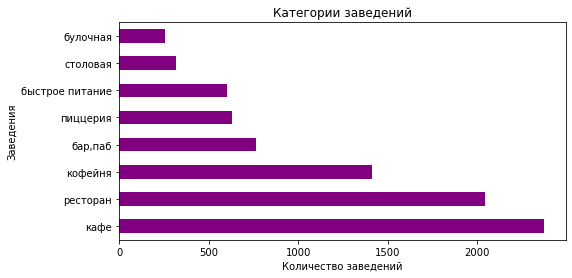

In [26]:
category_counts = dva_df['category'].value_counts()

category_counts.plot (kind='barh',
                      figsize=(8,4),
                      color='purple') 

plt.title('Категории заведений')
plt.xlabel('Количество заведений')
plt.ylabel('Заведения')
plt.show()

##### Промежуточный вывод 
Наибольшую долю занимают кафе (более 28%) и рестораны (24%). Вместе они составляют более половины всех заведений.
Кофейни занимают третье место (почти 17%).
Наименее распространены булочные и столовые (менее 4% каждая). Рынок общественного питания Москвы представлен преимущественно кафе и ресторанами; булочные и столовые встречаются значительно реже, что может быть связано с их ориентацией на специфическую аудиторию или меньшей популярностью.

Наиболее перспективен формат кофеен с потенциалом масштабирования. В сегменте кафе и ресторанов потребуется уникальная концепция из-за высокой конкуренции. Булочные и столовые как самостоятельный бизнес малоперспективны.

### 3.2 Задача 2
##### Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [27]:
district_df= pd.DataFrame({
    'Количество заведений по административным районам Москвы' : dva_df['district'].value_counts(),
    'Доля заведений по административным районам Москвы %' : (dva_df['district'].value_counts()/len(dva_df)*100).round(2)
})
display(district_df)

,Количество заведений по административным районам Москвы,Доля заведений по административным районам Москвы %
Центральный административный округ,2242,26.68
Северный административный округ,898,10.69
Южный административный округ,892,10.62
Северо-Восточный административный округ,890,10.59
Западный административный округ,850,10.12
Восточный административный округ,798,9.50
Юго-Восточный административный округ,714,8.50
Юго-Западный административный округ,709,8.44
Северо-Западный административный округ,409,4.87


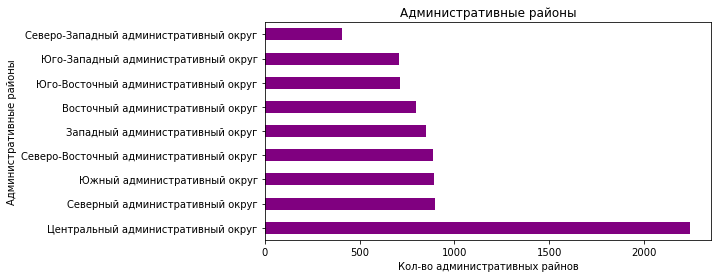

In [28]:
district_counts = dva_df['district'].value_counts()

district_counts.plot (kind='barh',
                      figsize=(8,4),
                      color='purple') 

plt.title('Административные районы')
plt.xlabel('Кол-во административных райнов')
plt.ylabel('Административные районы')
plt.show()

##### Промежуточный вывод
Наибольшее количество заведений приходится на рестораны (около 670) и кафе (около 460), что характерно для центральной части города с высокой концентрацией мест общественного питания. Наименьшее количество заведений в ЦАО составляют булочные, столовые и заведения быстрого питания (менее 100), что может быть связано с их ориентацией на спальные районы или меньшей популярностью в центре.

In [29]:
cao_df = dva_df[dva_df['district'] == 'Центральный административный округ']

cao_cat_counts = cao_df['category'].value_counts()
cao_cat_percent = (cao_cat_counts / len(cao_df) * 100).round(2)

cao_cat_stats = pd.DataFrame({
    'Количество': cao_cat_counts,
    'Доля в ЦАО (%)': cao_cat_percent
})
cao_cat_stats = cao_cat_stats.sort_values('Количество', ascending=False)
display(cao_cat_stats)

,Количество,Доля в ЦАО (%)
ресторан,670,29.88
кафе,464,20.70
кофейня,428,19.09
"бар,паб",364,16.24
пиццерия,113,5.04
быстрое питание,87,3.88
столовая,66,2.94
булочная,50,2.23


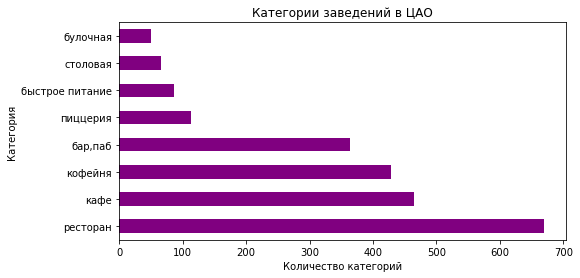

In [30]:
cao_data = dva_df[dva_df['district'] == 'Центральный административный округ']
cao_categories = cao_data['category'].value_counts()

cao_categories.plot(kind='barh', 
                    figsize=(8, 4), 
                    color='purple')

plt.title('Категории заведений в ЦАО')
plt.xlabel('Количество категорий')
plt.ylabel('Категория')
plt.show()

##### Промежуточный вывод 
В Центральном административном округе сосредоточено 2242 заведения (сумма по категориям). Распределение по категориям выглядит следующим образом:
Доминирование ресторанов, кафе и кофеен характерно для центра города, где высока концентрация мест для длительного досуга, деловых встреч и туристической активности.
Повышенная доля баров и пабов. Центр привлекает заведения с развлекательной направленностью.
Снижение доли «бытовых» форматов – столовые, булочные и заведения быстрого питания, что значительно ниже их общегородской доли. Это объясняется их ориентацией на спальные районы и меньшей востребованностью в центре из-за высокой арендной платы и другого профиля посетителей.

### 3.3 Задача 3
##### Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

'Общее количество заведений: 8402'

'Несетевые (chain=0): 5199 (61.9%)'

'Сетевые (chain=1):   3203 (38.1%)'

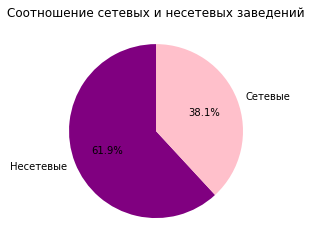

In [31]:
chain_counts = dva_df['chain'].value_counts()

non_chain = chain_counts[0] if 0 in chain_counts.index else 0
chain = chain_counts[1] if 1 in chain_counts.index else 0
total = len(dva_df)

display(f"Общее количество заведений: {total}")
display(f"Несетевые (chain=0): {non_chain} ({non_chain/total*100:.1f}%)")
display(f"Сетевые (chain=1):   {chain} ({chain/total*100:.1f}%)")

plt.figure(figsize=(4,4))
plt.pie([non_chain, chain], labels=['Несетевые', 'Сетевые'],
        autopct='%1.1f%%', colors=['purple', 'pink'], startangle=90)
plt.title('Соотношение сетевых и несетевых заведений')
plt.show()

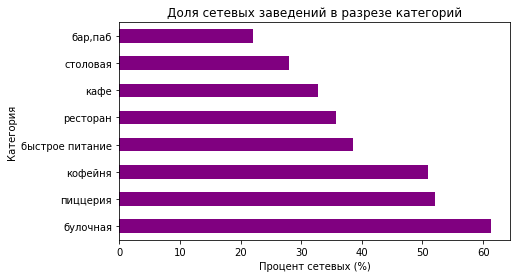

In [32]:
category_chain_share = dva_df.groupby('category')['chain'].mean() * 100
category_chain_share = category_chain_share.sort_values(ascending=False)

category_chain_share.plot(kind='barh',
                          figsize=(7,4),
                          color='purple')
plt.title('Доля сетевых заведений в разрезе категорий')
plt.xlabel('Процент сетевых (%)')
plt.ylabel('Категория')
plt.show()

##### Промежуточный вывод
Несетевые заведения составляют большинство – 61,9% (5199 из 8402), сетевые – 38,1% (3203). Это говорит о преобладании независимых точек общественного питания над франшизными или сетевыми форматами.
В разрезе категорий наблюдаются значительные различия. Наиболее высокая доля сетевых заведений характерна для булочных, пиццерий и кофеен – в этих сегментах сетевые форматы занимают лидирующие позиции (вероятно, благодаря успешным франшизам и тиражируемым концепциям). Напротив, бары, пабы и столовые чаще представлены несетевыми заведениями – здесь доля сетевых минимальна, что может быть связано с локальной спецификой и меньшей привлекательностью для масштабирования. 

Рынок открыт для новых проектов (почти 2/3 заведений – несетевые).Для масштабирования лучше всего подходят кофейни, пиццерии и булочные – там уже есть успешные сетевые модели, но и конкуренция выше.Для уникального формата выбирайте бары, пабы или столовые – здесь сетевых игроков почти нет, можно выделиться атмосферой и локальной концепцией. 

### 3.4 Задача 4
##### Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.

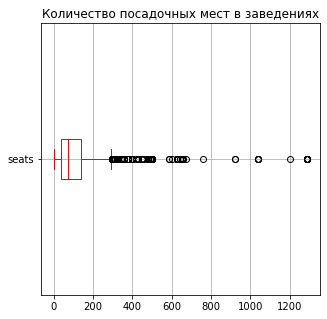

In [83]:
boxplot=dva_df.boxplot(column='seats',
                       vert=False,
                       figsize=(5,5),
                      color='red')
boxplot.set_title('Количество посадочных мест в заведениях')
plt.show()

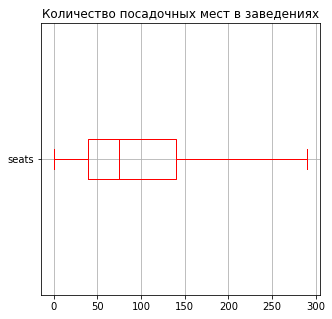

In [84]:
boxplot=dva_df.boxplot(column='seats',
                       vert=False,
                       figsize=(5,5),
                      showfliers=False,
                      color='red')
boxplot.set_title('Количество посадочных мест в заведениях')
plt.show()

In [33]:
median_seats_by_category = dva_df.groupby('category')['seats'].median().sort_values(ascending=False)
display("Медианное количество посадочных мест по категориям:")
display(median_seats_by_category)

'Медианное количество посадочных мест по категориям:'

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

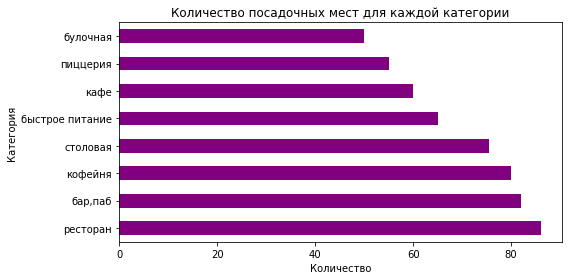

In [34]:
group_categories=dva_df.groupby('category')['seats'].median().sort_values(ascending=False)

group_categories.plot(kind='barh',
                      figsize=(8, 4), 
                      color='purple')

plt.title('Количество посадочных мест для каждой категории')
plt.xlabel('Количество')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

##### Промежуточный вывод
Основная масса заведений имеет от 20 до 80 посадочных мест (межквартильный размах), медиана составляет около 45–50 мест. Это характерно для небольших кафе, кофеен и ресторанов средней вместимости.
Аномальные значения и выбросы присутствуют: есть заведения с количеством мест более 200, вплоть до нескольких сотен. Такие выбросы могут быть связаны с крупными ресторанами, столовыми на предприятиях, фуд-кортами или заведениями, ориентированными на массовое обслуживание (например, «советские столовые», банкетные залы). На втором графике выбросы скрыты (параметр showfliers=False), однако их наличие подтверждается исходными данными.Типичное количество мест сильно зависит от категории заведения. Например, рестораны и бары в среднем имеют больше мест, чем пиццерии и булочные. 

# 3.5 Задача 5
Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [35]:
dva_df.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup,is_24_7
count,8402.000000,8402.000000,4792.000000,3149.000000,535.000000,8402.000000
mean,4.230017,0.381219,108.361436,958.053668,174.721495,0.086884
std,0.470320,0.485715,122.841130,1009.732845,88.951103,0.281682
min,1.000000,0.000000,0.000000,0.000000,60.000000,0.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000,0.000000
50%,4.300000,0.000000,75.000000,750.000000,169.000000,0.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000,0.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000,1.000000


In [36]:
dva_df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [37]:
category_r=dva_df.groupby('category')['rating'].agg(['mean']).round(2)
display(category_r)

,mean
category,
"бар,паб",4.39
булочная,4.27
быстрое питание,4.05
кафе,4.12
кофейня,4.28
пиццерия,4.30
ресторан,4.29
столовая,4.21


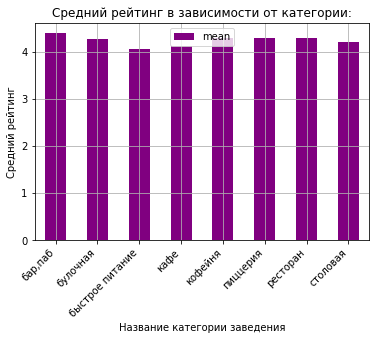

In [38]:
category1=dva_df.groupby('category')['rating'].agg(['mean']).round(2)

category1.plot(kind='bar',
               color='purple',
               grid= True
               )

plt.title("Средний рейтинг в зависимости от категории:")
plt.xlabel('Название категории заведения')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45, ha='right')
plt.show()

##### Промежуточный вывод
Наибольшие средние рейтинги наблюдаются у баров/пабов (около 4.39), пиццерий (4.30) и ресторанов (4.29). Чуть ниже – у кофеен (4.28) и булочных (4.27). Самые низкие средние оценки у кафе (4.12) и заведений быстрого питания (4.05). Разница между максимальным и минимальным средним рейтингом составляет около 0.34 балла, что нельзя назвать сильным разбросом – скорее, все категории имеют достаточно высокие и близкие оценки. Тем не менее, тенденция прослеживается: форматы с более высоким средним чеком и длительным пребыванием (рестораны, бары) получают несколько более высокие оценки, чем демократичные форматы (кафе, фастфуд). Это может объясняться разными ожиданиями посетителей и качеством обслуживания.

### 3.6 Задача 6
##### Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [39]:
cols = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
df_corr = dva_df[cols].copy()

for col in ['category', 'district', 'price']:
    df_corr[col] = df_corr[col].astype(str)

interval_cols = ['rating', 'seats', 'chain', 'is_24_7']

phik_corr = phik_matrix(df_corr, interval_cols=interval_cols)

rating_corr = phik_corr['rating'].drop('rating').sort_values(ascending=False)
display('Корреляция рейтинга:', rating_corr)

'Корреляция рейтинга:'

price       0.281253
district    0.200761
category    0.189716
is_24_7     0.150365
chain       0.107833
seats       0.000000
Name: rating, dtype: float64

In [40]:
# Комментарий ревьюера 2
len(dva_df), len(df_corr)

(8402, 8402)

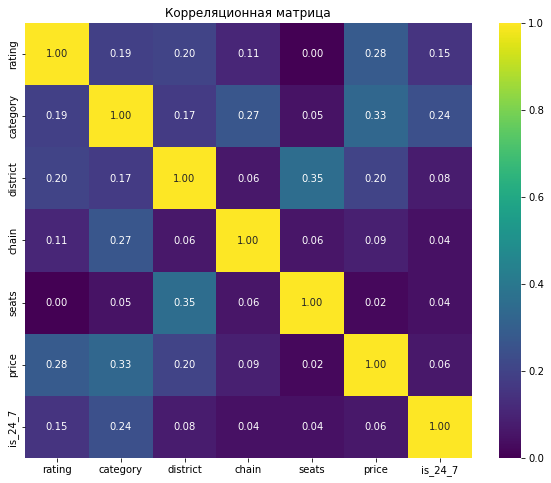

'Наиболее сильная связь: price  = 0.281)'

In [41]:
plt.figure(figsize=(10,8))
sns.heatmap(phik_corr, annot=True, cmap='viridis', vmin=0, vmax=1, fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

best = rating_corr.index[0]
best_val = rating_corr.iloc[0]
display(f'Наиболее сильная связь: {best}  = {best_val:.3f})')

##### Промежуточный вывод
Самым сильным фактором, связанным с рейтингом заведений, является ценовая категория (price) с коэффициентом 0.28. Чуть слабее, но всё же значимо, проявляется связь с административным округом (district) — 0.20, а также с категорией заведения (category) — 0.19. Признаки круглосуточной работы (is_24_7) и сетевого статуса (chain) показывают очень слабую корреляцию (0.15 и 0.11 соответственно), а количество посадочных мест (seats) вообще не влияет на рейтинг (коэффициент 0.00).

Цена — главный сигнал качества.
Положительная корреляция между ценой и рейтингом означает, что более дорогие заведения в среднем оцениваются выше. Высокий чек часто ассоциируется с лучшим сервисом, качеством продуктов и атмосферой. В низком и среднем ценовом сегменте конкуренция выше, и удержать рейтинг сложнее.

Местоположение остаётся важным, но не определяющим.
Связь с районом (0.20) подтверждает, что в центре и на западе Москвы заведения в среднем имеют более высокие рейтинги, чем на периферии. Однако эта связь слабее, чем влияние цены.Открываясь в центре, вы автоматически получаете «бонус» к ожиданиям публики, но это не гарантирует высоких оценок — решающим остаётся соотношение цены и качества.

Количество мест не имеет значения. Нулевая корреляция с seats говорит о том, что посетителям всё равно, рассчитано ли заведение на 20 или на 200 человек. Оценки ставят за атмосферу, еду и обслуживание, а не за вместимость.
Вывод: не стоит переплачивать за огромные площади в надежде, что это повысит рейтинг. Лучше сосредоточиться на качестве.

Сетевой статус и круглосуточность почти не влияют.
Очень слабая связь (0.11 и 0.15) означает, что быть сетевым или работать 24/7 само по себе не добавляет очков к репутации. 

In [42]:
price = dva_df.groupby('price')['rating'].agg(['count', 'mean', 'median', 'std'])
price = price.sort_values('mean', ascending=False)
display(price)

,count,mean,median,std
price,,,,
высокие,478,4.436611,4.4,0.314197
выше среднего,564,4.386348,4.4,0.223507
средние,2117,4.297874,4.3,0.295653
низкие,156,4.173077,4.2,0.372671


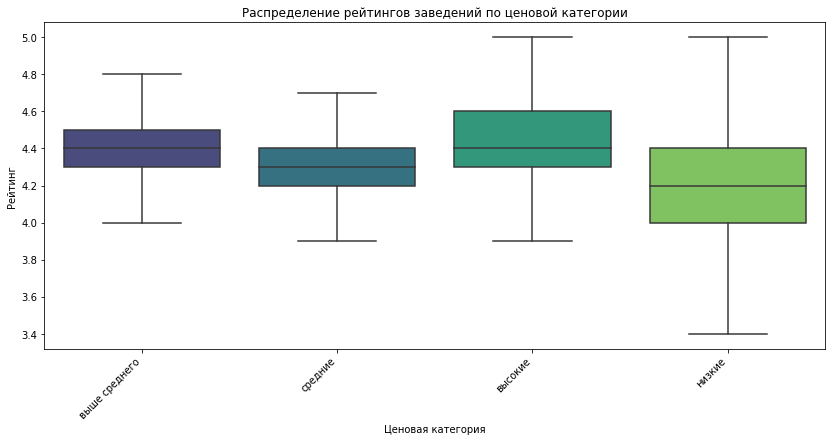

In [43]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=dva_df, x='price', y='rating', palette='viridis', showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title('Распределение рейтингов заведений по ценовой категории')
plt.ylabel('Рейтинг')
plt.xlabel('Ценовая категория')
plt.show()

##### Промежуточный вывод
С ростом цены растёт и средний рейтинг. Самый низкий – у «низких» (4.17), самый высокий – у «высоких» (4.44). Наименьший разброс оценок – в категории «выше среднего» (0.224). Это значит, что заведения этой группы наиболее предсказуемо получают высокие оценки. В категории «высокие» разброс чуть больше (0.314) – есть как лидеры, так и заведения, не оправдывающие ожиданий.
Ниша «низких»: здесь мало заведений (всего 156) и самый большой разброс. Рынок дешёвого общепита неоднороден: одни точки держат марку, другие проваливаются.
Если ваша цель – стабильно высокий рейтинг, оптимальной стратегией может быть позиционирование в категории «выше среднего». Она сочетает достаточно высокий средний балл (4.39) с минимальным риском получить низкие оценки. Это «золотая середина», где клиенты уже готовы платить больше, но ещё не предъявляют завышенных требований.

Выход в категорию «высокие» сулит максимальные рейтинги, но требует безупречного качества. Больший разброс означает, что ошибки здесь прощаются хуже: одно неудачное впечатление может сильно испортить общую оценку. Инвестору, выбирающему этот сегмент, нужно быть готовым к серьёзным вложениям в сервис, интерьер и продукт.

Категория «низкие» – зона высокого риска и нестабильности. Здесь трудно выделиться, а рейтинги в среднем ниже. Если вы планируете демократичное заведение, придётся очень стараться, чтобы переломить общую тенденцию и получить оценку выше 4.2. Малое количество конкурентов в этой нише может быть плюсом, но и говорит о её сложности.

Ценовая политика напрямую влияет не только на ожидаемую оценку, но и на её стабильность. Самый предсказуемый путь к высоким рейтингам – сегмент «выше среднего». Премиум-сегмент даёт шанс на максимум, но требует максимальной отдачи. Бюджетный сегмент – наиболее рискованный с точки зрения репутации.

### 3.7 Задача 7
##### Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [44]:
networks = dva_df[dva_df['chain'] == 1].copy()

top = (networks.groupby(networks['name'].str.lower().str.strip()).agg(
        name=('name', 'first'),          
        count=('name', 'size'),              
        avg_rating=('rating', 'mean'),        
        main_category=('category', lambda x: x.mode()[0] if len(x.mode()) > 0 else None)
    ).sort_values('count', ascending=False).head(15).reset_index(drop=True)
)

top['name'] = top['name'].str.lower()
top['avg_rating'] = top['avg_rating'].round(2)
display("Топ‑15 сетевых заведений Москвы:")
display(top[['name', 'main_category','count', 'avg_rating']])

'Топ‑15 сетевых заведений Москвы:'

,name,main_category,count,avg_rating
0,шоколадница,кофейня,120,4.18
1,домино'с пицца,пиццерия,76,4.17
2,додо пицца,пиццерия,74,4.29
3,one price coffee,кофейня,71,4.06
4,яндекс лавка,ресторан,69,3.87
5,cofix,кофейня,65,4.08
6,prime,ресторан,50,4.12
7,хинкальная,кафе,44,4.32
8,кофепорт,кофейня,42,4.15
9,кулинарная лавка братьев караваевых,кафе,39,4.39


In [45]:
# Комментарий ревьюера 2
tmp = dva_df.copy()          # создаем копию текущего датасета
name_tmp = 'Му-Му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем Му-Му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


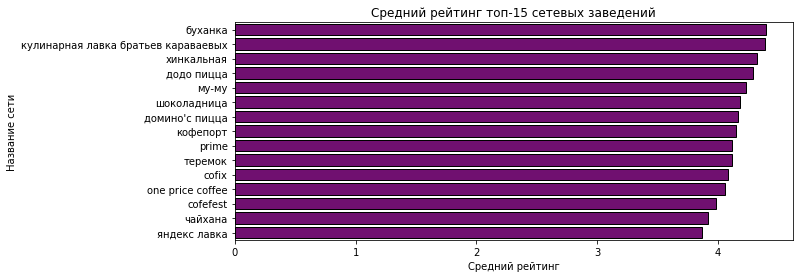

In [46]:
top = top.sort_values('avg_rating', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=top, y='name', x='avg_rating', color='purple', edgecolor='black')
plt.title('Средний рейтинг топ‑15 сетевых заведений')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.show()

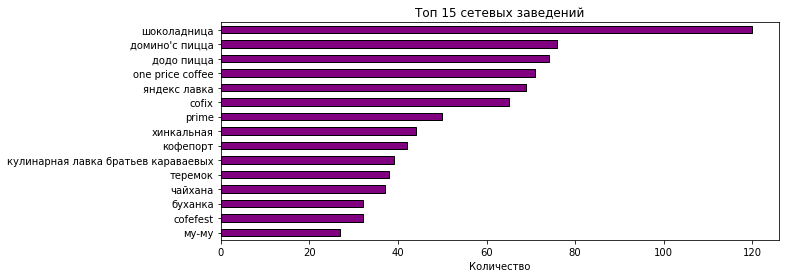

In [47]:
networks = dva_df[dva_df['chain'] == 1]
top_15 = networks['name'].str.lower().str.strip().value_counts().head(15)
top_15 = top_15.sort_values(ascending=True)

top_15.plot(kind='barh',
           figsize=(10,4),
           color='purple',
           edgecolor='black'
          )
plt.title('Топ 15 сетевых заведений')
plt.xlabel('Количество')
plt.show()

##### Промежуточный вывод

Визуализация топ-15 сетевых заведений по количеству точек показывает, что лидеры по числу заведений («Шоколадница», кофейни и пиццерии) не обладают самыми высокими рейтингами. Напротив, сети с меньшим масштабом («Буханка», «Кулинарная лавка братьев Караваевых») получают более высокие оценки, что свидетельствует об отсутствии прямой зависимости между количеством точек и качеством обслуживания. 

Разброс средних рейтингов: самые высокие оценки получили сети «Буханка» (4.40), «Кулинарная лавка братьев Караваевых» (4.39) и «Хинкальная» (4.32). Примечательно, что эти сети имеют сравнительно небольшое количество точек (32, 39 и 44 соответственно).

Зависимость «количество – качество»: прямой связи между масштабом сети и её средним рейтингом не наблюдается. Напротив, сети с умеренным числом точек часто демонстрируют более высокие оценки, что может свидетельствовать о сложности поддержания стабильного качества при быстром росте.

### 3.8 Задача 8 
##### Изучите вариацию среднего чека заведения (столбец middle_avg_bill) в зависимости от района Москвы. Проанализируйте цены в центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.

In [48]:
dva_df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

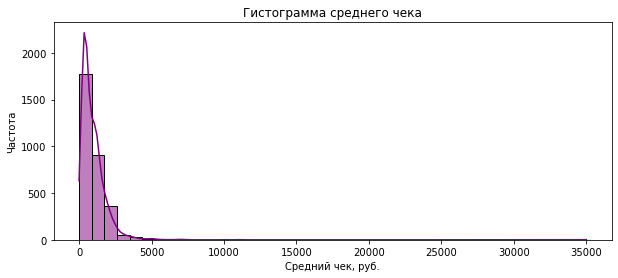

In [49]:
plt.figure(figsize=(10, 4))

sns.histplot(dva_df['middle_avg_bill'], bins=40, kde=True, color='purple')
plt.title('Гистограмма среднего чека')
plt.xlabel('Средний чек, руб.')
plt.ylabel('Частота')

plt.show()

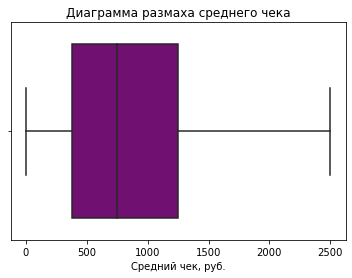

In [50]:
sns.boxplot(x=dva_df['middle_avg_bill'], color='purple', showfliers=False)
plt.title('Диаграмма размаха среднего чека')
plt.xlabel('Средний чек, руб.')
plt.show()

##### Промежуточный вывод
Разрыв между средним (958 руб.) и медианным (750 руб.) средним чеком говорит о том, что рынок общепита Москвы поляризован: основная масса заведений работает в демократичном сегменте (медиана 750 руб.), но существует небольшая прослойка дорогих ресторанов, которые сильно повышают среднее значение. Массовый сегмент (чек до 1000 руб.) – самый конкурентный, но и самый ёмкий. Здесь высокая частота посещений, но низкая маржинальность.
Премиум-сегмент (чек от 1500 руб.) – менее конкурентен, но требует серьёзных вложений в качество и атмосферу. Разброс чеков в центре (1191 руб.) и на периферии (654 руб.) показывает, что локация критически влияет на ценовую политику: в ЦАО можно закладывать более высокий чек, в спальных районах – ориентироваться на местную аудиторию с невысокими доходами.

In [51]:
order = dva_df.groupby('district')['middle_avg_bill'].agg(
    median= 'median',
    mean= 'mean'
    ).sort_values('median', ascending=False)
display(order)

,median,mean
district,,
Западный административный округ,1000.0,1053.225490
Центральный административный округ,1000.0,1191.057547
Северо-Западный административный округ,700.0,822.222930
Северный административный округ,650.0,927.959627
Юго-Западный административный округ,600.0,792.561702
Восточный административный округ,575.0,820.626923
Северо-Восточный административный округ,500.0,716.611296
Южный административный округ,500.0,834.398089
Юго-Восточный административный округ,450.0,654.097938


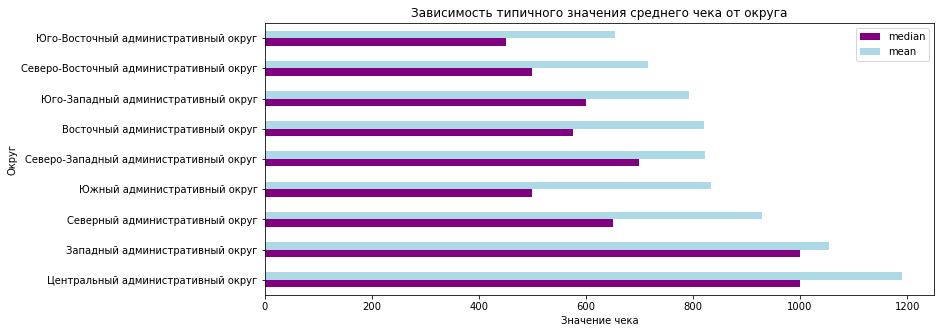

In [52]:
order = dva_df.groupby('district')['middle_avg_bill'].agg(
    median= 'median',
    mean= 'mean'
    ).sort_values([ 'mean','median'], ascending=False)

order.plot(kind='barh',
           figsize=(12,5),
           color=['purple','lightblue'],
           )
plt.title('Зависимость типичного значения среднего чека от округа')
plt.xlabel('Значение чека')
plt.ylabel('Округ')
plt.show()

##### Промежуочный вывод
Западный административный округ (медиана 1000 руб., среднее 1053 руб.) и Центральный административный округ (медиана 1000 руб., среднее 1191 руб.) демонстрируют максимальные значения как по медиане, так и по среднему. Это наиболее престижные и дорогие районы города с высокой концентрацией офисов, туристических мест и жилой недвижимости бизнес- и премиум-класса. Здесь сосредоточены рестораны высокой кухни, дорогие кафе и бары, ориентированные на платёжеспособную аудиторию. Более высокое среднее значение по сравнению с медианой в ЦАО указывает на наличие заведений с экстремально высокими чеками (элитные рестораны), которые «тянут» среднее вверх.
Наиболее низкие медианные значения зафиксированы в Юго-Восточном административном округе (450 руб.), Северо-Восточном и Южном (по 500 руб.). Средние значения в этих округах также минимальны (от 654 до 834 руб.)Это периферийные, преимущественно спальные и промышленные районы с менее платёжеспособным населением. Здесь преобладают заведения демократичного формата – столовые, кафе быстрого питания, пиццерии, ориентированные на местных жителей и работников близлежащих предприятий. Более низкая арендная плата также способствует снижению цен.
В Северном административном округе наблюдается значительный разрыв между медианой (650 руб.) и средним значением (928 руб.). Это указывает на наличие в этом округе небольшого числа заведений с очень высоким средним чеком (возможно, рестораны в новых жилых комплексах бизнес-класса или при гостиницах), которые существенно повышают общее среднее, но не влияют на медиану.
Аналогичная, но менее выраженная картина видна в Южном округе (медиана 500 руб., среднее 834 руб.) – там тоже присутствуют выбросы.
Прослеживается чёткая обратная зависимость между удалённостью от центра и уровнем цен:
Центр и Запад – максимальные чеки.
Ближнее кольцо (Северо-Западный, Северный, Юго-Западный) – средние чеки 600–700 руб.
Восточные и южные округа – чеки 500–575 руб.
Периферия (Юго-Восточный) – минимальные чеки 450 руб.

## Обобщающий вывод по разделу 3
Категории заведений: кафе (28%) и рестораны (24%) доминируют; булочные и столовые – менее 4%.
Самые массовые сегменты – самые конкурентные. Входить в них стоит только с сильной концепцией или уникальным предложением.
Малочисленные форматы (булочные, столовые) могут быть нишами с низкой конкуренцией, но их аудитория специфична (например, офисные работники, жители спальных районов).

Административные округа: ЦАО концентрирует 27% всех заведений, при этом в центре преобладают рестораны, кафе и бары; на периферии выше доля столовых и булочных. Высокая плотность в центре означает жёсткую конкуренцию, но и высокий трафик. Инвестору нужно решить, готов ли он к борьбе за клиента в центре или выберет менее насыщенный, но более стабильный спальный район.
В спальных районах востребованы форматы «повседневного спроса» – столовые, пиццерии, булочные.

Сетевые форматы: 62% заведений – несетевые; сетевые преобладают в булочных, пиццериях и кофейнях. Топ-15 сетей: «Шоколадница», «Домино’с Пицца», «Додо Пицца» – лидеры по числу точек, но не по рейтингу. Высокая доля сетевых в некоторых категориях говорит о том, что эти форматы хорошо масштабируются (франшизы, типовые решения). Обратная зависимость «количество – качество» предупреждает: быстрый рост может привести к падению рейтинга. При масштабировании необходимо жёстко контролировать стандарты.

Посадочные места: медианное количество мест сильно различается по категориям (рестораны ~86, булочные ~50); есть заведения-гиганты (>200 мест). Корреляция с рейтингом нулевая. Вместимость не влияет на оценку – клиенты голосуют за еду и сервис, а не за размер зала. Инвестиции в огромные площади не окупятся ростом рейтинга.

Рейтинги и факторы успеха: средний рейтинг по Москве – 4,23; самые высокие оценки у баров (4,39), пиццерий (4,30), ресторанов (4,29).
Корреляция рейтинга:
цена – 0,28
округ – 0,20
категория – 0,19
is_24_7 – 0,15
chain – 0,11
seats – 0,00
Цена – главный драйвер рейтинга. Высокий чек ассоциируется с качеством. Но сегмент «выше среднего» даёт наименьший разброс оценок – это «золотая середина», где клиенты уже готовы платить, но ещё не предъявляют завышенных требований.
Местоположение важно, но не определяюще. Открываясь в центре, вы получаете «аванс» доверия, но подтвердить его нужно качеством.
Количество мест не имеет значения. Не тратьте бюджет на огромные залы. Сетевой статус и круглосуточность – слабые факторы. Само по себе наличие бренда или работа 24/7 не повышает рейтинг.

Средний чек: медиана – 750 руб., среднее – 958 руб. (поляризация). По округам: ЦАО и ЗАО – 1000 руб., ЮВАО – 450 руб.
Основной рынок – демократичный сегмент (до 1000 руб.). Здесь высокая частота посещений, но низкая маржинальность.
Премиум-сегмент (от 1500 руб.) менее конкурентен, но требует серьёзных вложений. Разница в чеках по округам диктует ценовую стратегию: в центре можно ставить цену выше, на периферии – ориентироваться на местную аудиторию.

## 4. Заключение

Целью данного исследования было проведение всестороннего анализа рынка общественного питания Москвы для предоставления инвестиционному фонду «Shut Up and Take My Money» рекомендаций по открытию нового заведения. Основные задачи включали анализ структуры рынка (типы заведений, их концентрация по административным округам), изучение сетевых форматов, оценку факторов, влияющих на рейтинг и средний чек (количество посадочных мест, ценовая политика, расположение)

Структура рынка: Рынок Москвы характеризуется доминированием кафе, ресторанов и кофеен. При этом наблюдается ярко выраженная централизация: Центральный административный округ (ЦАО) является безусловным лидером по концентрации заведений, особенно ресторанов, в то время как булочные и столовые тяготеют к спальным районам. Это говорит о разных бизнес-моделях и аудиториях в центре и на периферии.

Сетевые форматы: Большинство заведений (62%) являются несетевыми. Однако анализ показал, что булочные, пиццерии и кофейни имеют наибольшую долю сетевых игроков, что указывает на их высокую масштабируемость. В то же время, анализ топ-15 сетей выявил обратную зависимость: крупнейшие по количеству точки сети ("Кафе", "Шоколадница") часто имеют более низкие рейтинги по сравнению с менее масштабными, что может сигнализировать о сложностях с поддержанием качества при быстром росте.

Посадочные места: Закономерно, что наибольшей вместимостью обладают рестораны, бары и кофейни (типичный диапазон 55–85 мест), ориентированные на длительное пребывание гостей. Пиццерии и булочные, напротив, имеют меньше мест, что соответствует формату «быстрого перекуса» и работы «на вынос».

Рейтинги: Распределение рейтингов асимметрично (среднее значение ниже медианы), что вызвано наличием большого числа заведений с низкими оценками. Корреляционный анализ показал, что из всех рассмотренных факторов (категория, сетевость, количество мест, цена) наиболее заметная связь наблюдается с административным районом. Это подтверждает гипотезу о влиянии локации на восприятие и успех заведения.

Ценовая политика: Выявлена четкая зависимость среднего чека от удаленности от центра. Самые высокие средние чеки зафиксированы в ЦАО и Западном административном округе (ЗАО), в то время как на периферии (например, в Юго-Восточном округе) они значительно ниже. Эта разница обусловлена как разницей в платежеспособности аудитории, так и преобладанием в центре более дорогих форматов заведений.

Предобработка данных сыграла ключевую роль в обеспечении достоверности выводов. Корректное объединение таблиц, удаление столбца middle_coffee_cup с критическим уровнем пропусков (>93%), а также очистка от неявных дубликатов позволили получить непротиворечивый набор данных. Заполнение пропусков в столбце seats медианными значениями по категориям было оправдано, так как вместимость напрямую зависит от типа заведения. Это позволило сохранить важные данные и провести корректный анализ посадочных мест без искажения статистики выбросами.

Рекомендации:
Для открытия кафе или ресторана с высоким средним чеком наиболее перспективными локациями являются ЦАО и ЗАО, где сконцентрирована платежеспособная аудитория и высокая проходимость. Однако здесь велика конкуренция.
Для форматов, ориентированных на быстрый оборот и массового потребителя (булочные, столовые, пиццерии), более рациональным будет выбор спальных районов (например, Юго-Восточный или Северо-Восточный округа), где спрос на такие услуги высок, а конкуренция и уровень издержек ниже.
Стратегия масштабирования: Если планируется развитие сети, наиболее подходящими форматами являются булочные, пиццерии и кофейни. При масштабировании необходимо сделать особый упор на стандартизацию и контроль качества, так как анализ топ-сетей показывает риск его снижения при увеличении числа точек.
Рейтинг и сервис: Учитывая, что рейтинг сильнее всего связан с районом, в центре рекомендуется делать ставку на уникальный сервис и атмосферу, чтобы выделиться на фоне высокой конкуренции. На периферии ключевыми факторами успеха станут стабильность качества и адекватные цены.
Ценовая политика: Рекомендуется устанавливать цены, ориентируясь на средний чек по округу. В центре допустима более высокая наценка, в спальных районах — стратегия доступных цен для привлечения локального потока посетителей.